# 01 - Data Exploration

Raw and processed data for the vegetable price forecasting project: prices (2000-2025), diesel/petrol fuel prices (2015-2025), and district-wise weather (2013-2026). This notebook is exploratory only - production logic lives in `src/`, per CLAUDE.md.

In [ ]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import matplotlib.pyplot as plt

from src.utils.io import load_config

config = load_config()
config['vegetables']

['carrot', 'brinjal', 'pumpkin', 'cabbage', 'snake_gourd', 'leeks']

## Raw sources

In [ ]:
prices = pd.read_csv('../data/raw/vegetable_prices/vegetable_prices.csv', parse_dates=['week_start'])
fuel = pd.read_csv('../data/raw/fuel/fuel_data_weekly.csv', parse_dates=['date'])
weather = pd.read_csv('../data/raw/weather/weather.csv', parse_dates=['week_start_date'])

print(prices.shape, fuel.shape, weather.shape)
prices.head()

(8112, 4) (574, 3) (16400, 4)


,vegetable,week_start,wholesale_price,retail_price
0,BRINJALS,2000-01-03,19.20,40.00
1,BRINJALS,2000-01-10,12.80,37.89
2,BRINJALS,2000-01-17,11.20,33.69
3,BRINJALS,2000-01-24,9.73,29.47
4,BRINJALS,2000-01-31,10.13,32.60


## Retail price trend per vegetable

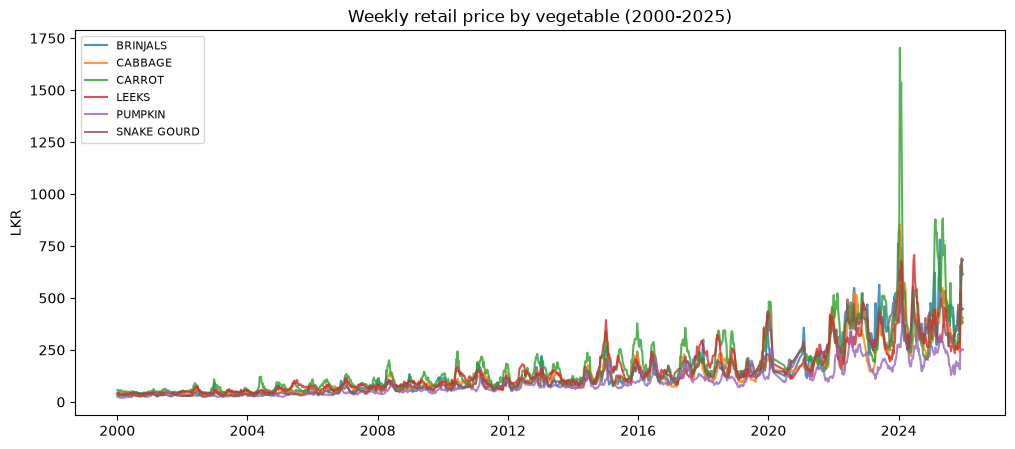

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
for veg, grp in prices.groupby('vegetable'):
    ax.plot(grp['week_start'], grp['retail_price'], label=veg, alpha=0.8)
ax.set_title('Weekly retail price by vegetable (2000-2025)')
ax.set_ylabel('LKR')
ax.legend(loc='upper left', fontsize=8)
plt.show()

## Fuel price trend (diesel is the transport-cost driver used as an exogenous feature)

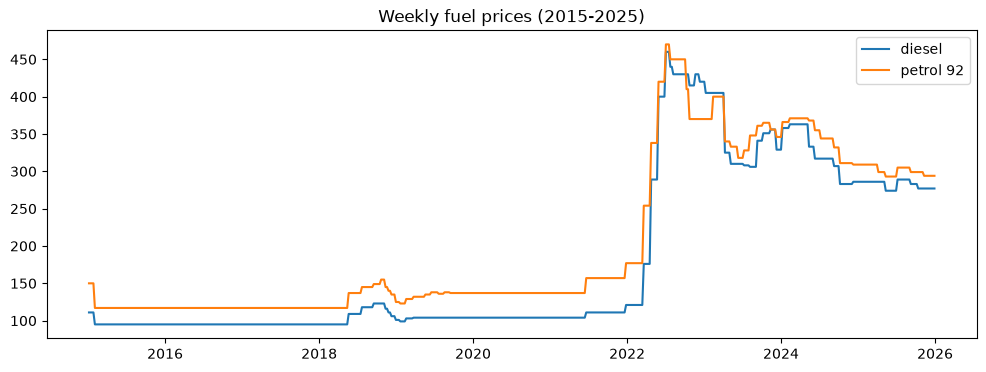

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(fuel['date'], fuel['diesel_price'], label='diesel')
ax.plot(fuel['date'], fuel['petrol92_price'], label='petrol 92')
ax.set_title('Weekly fuel prices (2015-2025)')
ax.legend()
plt.show()

## Weather: representative districts per the mapping in `configs/config.yaml`

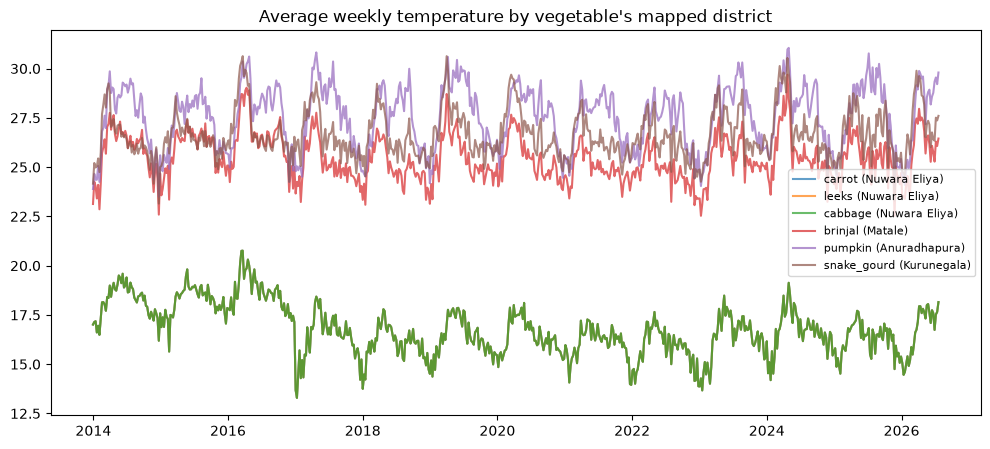

In [ ]:
district_map = config['weather_district_map']
fig, ax = plt.subplots(figsize=(12, 5))
for veg, district in district_map.items():
    d = weather[weather['district'] == district]
    ax.plot(d['week_start_date'], d['average_temperature'], label=f'{veg} ({district})', alpha=0.7)
ax.set_title('Average weekly temperature by vegetable\'s mapped district')
ax.legend(fontsize=8)
plt.show()

## Processed per-vegetable datasets (after `build_dataset.py` merges all 3 sources)

In [ ]:
carrot = pd.read_csv('../data/processed/carrot.csv', parse_dates=['date'])
carrot.describe()

,date,retail_price,wholesale_price,average_temperature,average_rainfall,diesel_price
count,571,571.000000,571.000000,571.000000,571.000000,571.000000
mean,2020-07-01 13:29:31.628721,287.096638,183.704614,16.657233,5.499317,180.914186
min,2015-01-05 00:00:00,94.047619,37.920000,13.290000,0.000000,95.000000
25%,2017-10-05 12:00:00,173.000000,97.500000,15.830000,1.630000,95.000000
50%,2020-06-29 00:00:00,232.258065,135.833333,16.530000,3.510000,104.000000
75%,2023-03-30 12:00:00,360.374332,227.500000,17.420000,7.015000,286.000000
max,2025-12-22 00:00:00,1703.333333,1395.833333,20.760000,66.040000,460.000000
std,NaN,174.274885,144.520345,1.255047,6.238894,114.539710


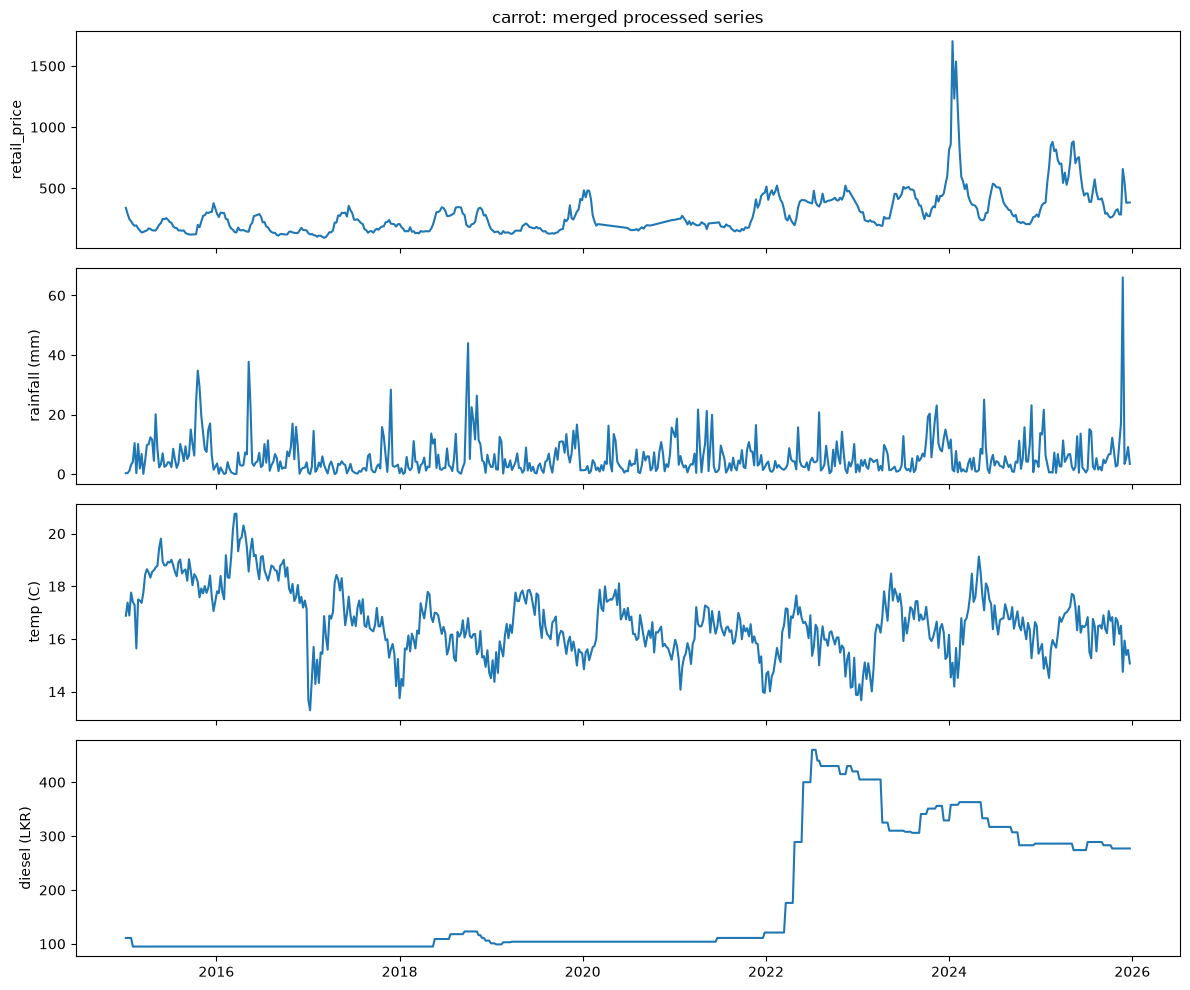

In [ ]:
fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
axes[0].plot(carrot['date'], carrot['retail_price']); axes[0].set_ylabel('retail_price')
axes[1].plot(carrot['date'], carrot['average_rainfall']); axes[1].set_ylabel('rainfall (mm)')
axes[2].plot(carrot['date'], carrot['average_temperature']); axes[2].set_ylabel('temp (C)')
axes[3].plot(carrot['date'], carrot['diesel_price']); axes[3].set_ylabel('diesel (LKR)')
axes[0].set_title('carrot: merged processed series')
plt.tight_layout(); plt.show()

## Correlation between exogenous drivers and price

In [ ]:
carrot[['retail_price', 'average_rainfall', 'average_temperature', 'diesel_price']].corr()

,retail_price,average_rainfall,average_temperature,diesel_price
retail_price,1.000000,-0.032658,-0.266239,0.562886
average_rainfall,-0.032658,1.000000,0.001671,0.015534
average_temperature,-0.266239,0.001671,1.000000,-0.239395
diesel_price,0.562886,0.015534,-0.239395,1.000000
